# Titanic Survival Prediction: End-to-End Machine Learning Pipeline
**Author**: Data Science & Machine Learning Engineering  
**Tech Stack**: Python 3.13, pandas, NumPy, Matplotlib, Seaborn, scikit-learn  
**Task Type**: Binary Classification (Supervised Learning)  
**Objective**: Build a robust, leak-free predictive classification system to predict passenger survival aboard the RMS Titanic based on demographic, familial, and ticketing data.

---

### Project Structure & Methodology
1. **Data Ingestion & Integrity Audit**: Inspecting data types, distributions, and missingness.
2. **Exploratory Data Analysis (EDA)**: Statistical interrogation of survival drivers (Sex, Pclass, Fare, Age).
3. **Domain-Driven Feature Engineering**: Deriving `FamilySize`, `IsAlone`, and extracting social `Title` from names.
4. **Leak-Free Preprocessing**: Constructing scikit-learn `Pipeline` and `ColumnTransformer` fitted strictly on training folds.
5. **Model Development**: Benchmarking an interpretable linear baseline (**Logistic Regression**) against a non-linear ensemble (**Random Forest Classifier**).
6. **Rigorous Evaluation**: 5-Fold Stratified Cross-Validation and holdout test set assessment using Accuracy, Precision, Recall, F1-Score, ROC-AUC, and Confusion Matrices.
7. **Feature Importance & Interpretability**: Model coefficient analysis and Random Forest Mean Decrease in Impurity (MDI).


In [1]:
# 1. Imports and Global Visualization Configurations
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)

# Visual styling
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.size'] = 11
plt.rcParams['figure.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 13
pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 1000)

print("Environment initialized successfully.")


Environment initialized successfully.


## 1. Data Ingestion & Initial Integrity Audit

We load the canonical Titanic passenger dataset containing 891 records across 12 raw attributes.


In [2]:
# Load Titanic dataset
data_path = os.path.join('..', 'data', 'titanic.csv')
if not os.path.exists(data_path):
    data_path = 'data/titanic.csv'

df = pd.read_csv(data_path)
print(f"Dataset Dimensions: {df.shape[0]} rows, {df.shape[1]} columns\n")
display(df.head())


Dataset Dimensions: 891 rows, 12 columns



,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
# Data Types and Missing Values Summary
audit_df = pd.DataFrame({
    'Data Type': df.dtypes,
    'Non-Null Count': df.notnull().sum(),
    'Null Count': df.isnull().sum(),
    'Null Percentage (%)': (df.isnull().sum() / len(df) * 100).round(2)
})
display(audit_df[audit_df['Null Count'] > 0])

print(f"\nOverall survival baseline rate: {df['Survived'].mean() * 100:.2f}% ({df['Survived'].sum()} survivors out of {len(df)})")


,Data Type,Non-Null Count,Null Count,Null Percentage (%)
Age,float64,714,177,19.87
Cabin,str,204,687,77.10
Embarked,str,889,2,0.22



Overall survival baseline rate: 38.38% (342 survivors out of 891)


### Missing Value Insights & Strategy:
* **Cabin**: ~77.1% missing. Due to high sparsity, using raw Cabin directly causes overfitting or requires drastic dropping.
* **Age**: 177 missing values (19.86%). Crucial biological predictor; will be imputed using the **median** within the preprocessing pipeline.
* **Embarked**: 2 missing values (0.22%). Imputed using the **mode / most frequent** port ('S').


## 2. Exploratory Data Analysis (EDA)

We investigate demographic, socioeconomic, and ticketing dimensions to identify survival patterns.


C:\Users\lenovo\AppData\Local\Temp\ipykernel_3088\1403518818.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[0].set_xticklabels(['Perished (0)', 'Survived (1)'])


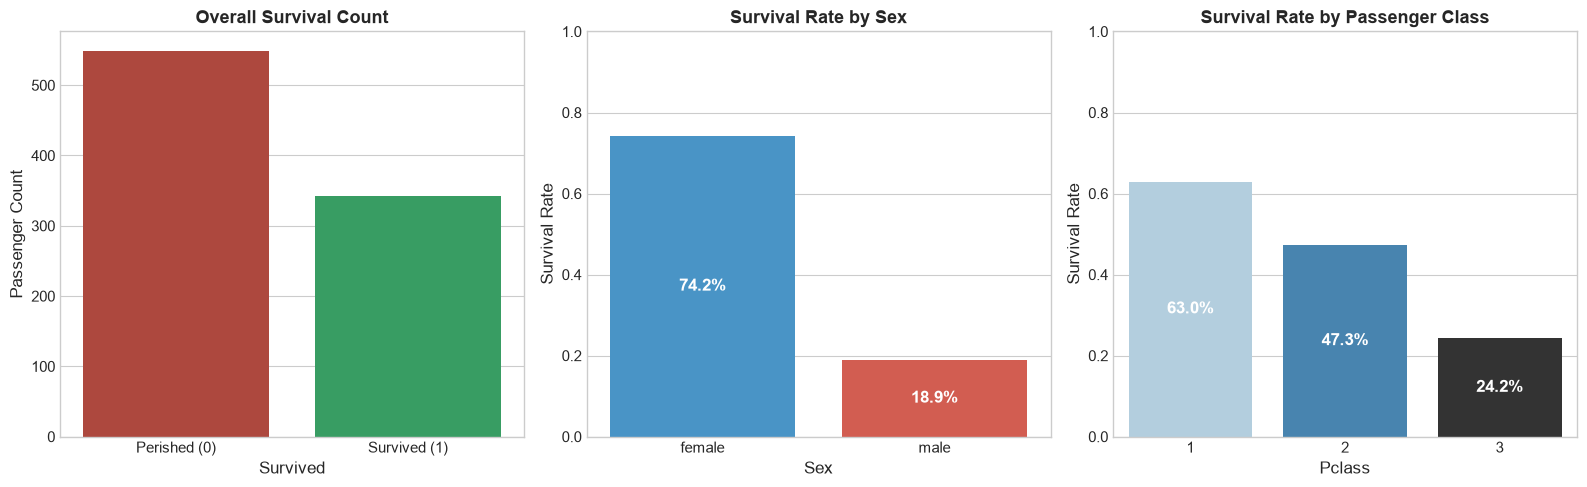

Female Survival Rate: 74.20%
Male Survival Rate  : 18.89%
1st Class Survival  : 62.96%
3rd Class Survival  : 24.24%


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Overall Survival Count
sns.countplot(data=df, x='Survived', palette=['#c0392b', '#27ae60'], ax=axes[0], hue='Survived', legend=False)
axes[0].set_title('Overall Survival Count', fontweight='bold')
axes[0].set_xticklabels(['Perished (0)', 'Survived (1)'])
axes[0].set_ylabel('Passenger Count')

# 2. Survival Rate by Sex
sex_surv = df.groupby('Sex')['Survived'].mean().reset_index()
sns.barplot(data=sex_surv, x='Sex', y='Survived', palette=['#3498db', '#e74c3c'], ax=axes[1], hue='Sex', legend=False)
axes[1].set_title('Survival Rate by Sex', fontweight='bold')
axes[1].set_ylabel('Survival Rate')
axes[1].set_ylim(0, 1.0)
for p in axes[1].patches:
    axes[1].annotate(f"{p.get_height()*100:.1f}%", (p.get_x() + p.get_width() / 2., p.get_height() / 2),
                     ha='center', va='center', color='white', fontweight='bold', fontsize=12)

# 3. Survival Rate by Passenger Class (Pclass)
pclass_surv = df.groupby('Pclass')['Survived'].mean().reset_index()
sns.barplot(data=pclass_surv, x='Pclass', y='Survived', palette='Blues_d', ax=axes[2], hue='Pclass', legend=False)
axes[2].set_title('Survival Rate by Passenger Class', fontweight='bold')
axes[2].set_ylabel('Survival Rate')
axes[2].set_ylim(0, 1.0)
for p in axes[2].patches:
    axes[2].annotate(f"{p.get_height()*100:.1f}%", (p.get_x() + p.get_width() / 2., p.get_height() / 2),
                     ha='center', va='center', color='white', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()

print(f"Female Survival Rate: {df[df['Sex']=='female']['Survived'].mean()*100:.2f}%")
print(f"Male Survival Rate  : {df[df['Sex']=='male']['Survived'].mean()*100:.2f}%")
print(f"1st Class Survival  : {df[df['Pclass']==1]['Survived'].mean()*100:.2f}%")
print(f"3rd Class Survival  : {df[df['Pclass']==3]['Survived'].mean()*100:.2f}%")


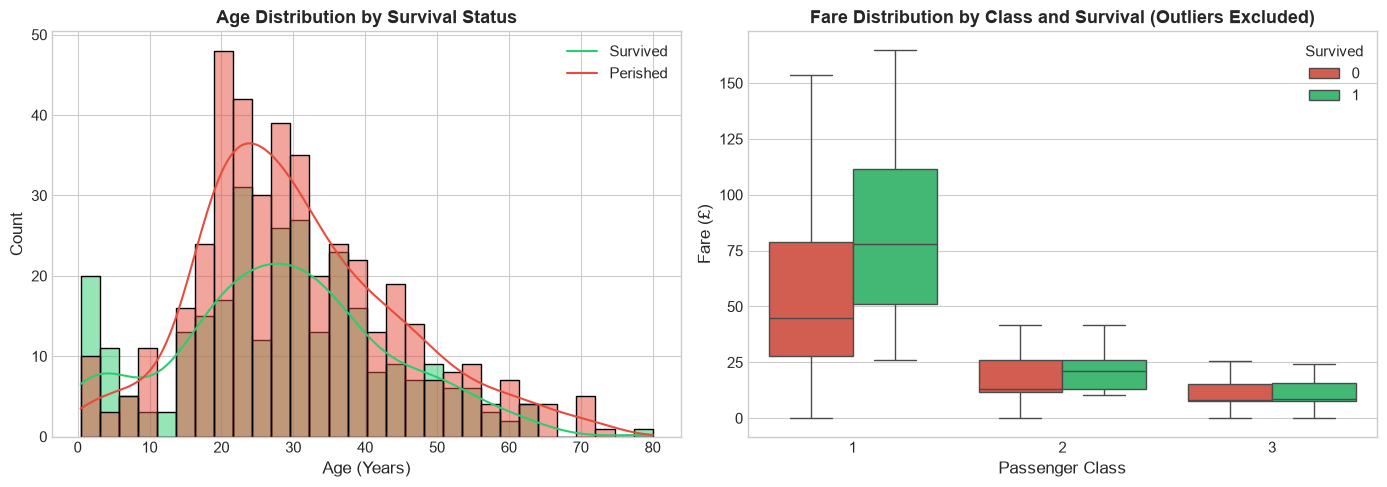

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Age Distribution by Survival Status
sns.histplot(data=df, x='Age', hue='Survived', kde=True, bins=30, palette=['#e74c3c', '#2ecc71'], ax=axes[0])
axes[0].set_title('Age Distribution by Survival Status', fontweight='bold')
axes[0].set_xlabel('Age (Years)')
axes[0].legend(['Survived', 'Perished'], loc='upper right')

# Fare Boxplot by Class and Survival
sns.boxplot(data=df, x='Pclass', y='Fare', hue='Survived', palette=['#e74c3c', '#2ecc71'], ax=axes[1], showfliers=False)
axes[1].set_title('Fare Distribution by Class and Survival (Outliers Excluded)', fontweight='bold')
axes[1].set_xlabel('Passenger Class')
axes[1].set_ylabel('Fare (£)')

plt.tight_layout()
plt.show()


## 3. Domain-Driven Feature Engineering

Raw data often contains implicit signals. We engineer three distinct features:
1. **FamilySize**: `SibSp` (siblings/spouses) + `Parch` (parents/children) + 1 (the passenger themself).
2. **IsAlone**: Binary indicator (1 if `FamilySize == 1`, else 0). Solo passengers had significantly lower survival rates due to lack of family priority during lifeboat loading.
3. **Title**: Extracted from passenger `Name` (e.g., 'Mr', 'Miss', 'Mrs', 'Master', and grouping rare aristocratic/officer titles into 'Rare').


In [6]:
df_feat = df.copy()

# 1. FamilySize
df_feat['FamilySize'] = df_feat['SibSp'] + df_feat['Parch'] + 1

# 2. IsAlone
df_feat['IsAlone'] = (df_feat['FamilySize'] == 1).astype(int)

# 3. Title Extraction
df_feat['Title'] = df_feat['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)
rare_titles = ['Lady', 'Countess', 'Capt', 'Col', 'Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona']
df_feat['Title'] = df_feat['Title'].replace(rare_titles, 'Rare')
df_feat['Title'] = df_feat['Title'].replace({'Mlle': 'Miss', 'Ms': 'Miss', 'Mme': 'Mrs'})
df_feat['Title'] = df_feat['Title'].fillna('Rare')

print("Title Frequencies:\n", df_feat['Title'].value_counts())


Title Frequencies:
 Title
Mr        517
Miss      185
Mrs       126
Master     40
Rare       23
Name: count, dtype: int64


C:\Users\lenovo\AppData\Local\Temp\ipykernel_3088\86259453.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_feat, x='FamilySize', y='Survived', palette='viridis', ax=axes[0], errorbar=None)
C:\Users\lenovo\AppData\Local\Temp\ipykernel_3088\86259453.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_feat, x='IsAlone', y='Survived', palette=['#3498db', '#95a5a6'], ax=axes[1], errorbar=None)
C:\Users\lenovo\AppData\Local\Temp\ipykernel_3088\86259453.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[1].set_xticklabels(['With Family (0)', 'Alone (1)

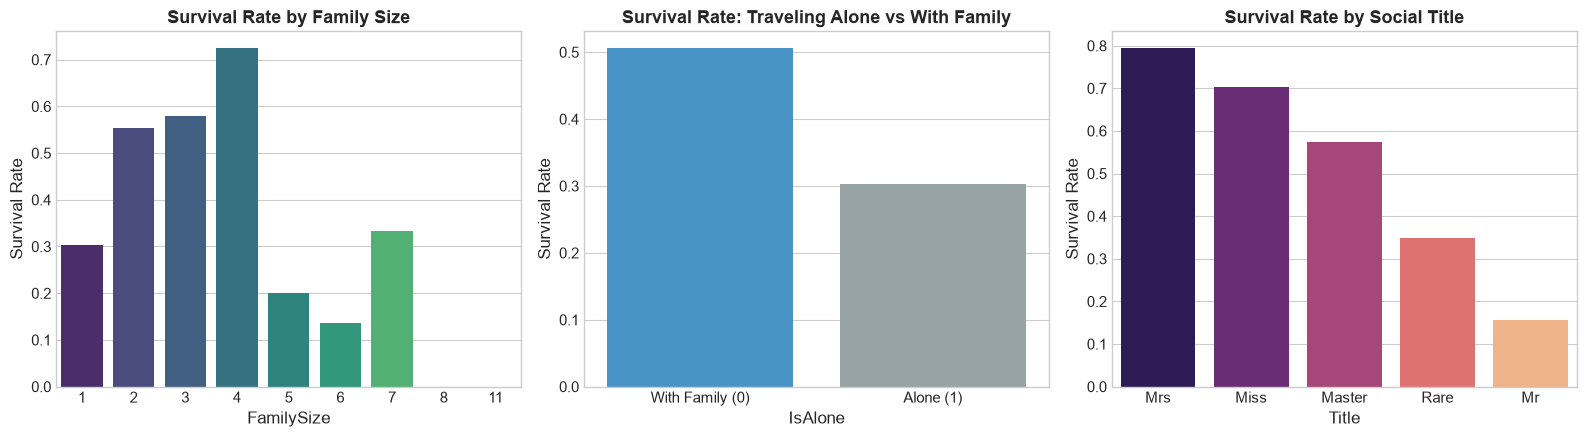

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# Survival by FamilySize
sns.barplot(data=df_feat, x='FamilySize', y='Survived', palette='viridis', ax=axes[0], errorbar=None)
axes[0].set_title('Survival Rate by Family Size', fontweight='bold')
axes[0].set_ylabel('Survival Rate')

# Survival by IsAlone
sns.barplot(data=df_feat, x='IsAlone', y='Survived', palette=['#3498db', '#95a5a6'], ax=axes[1], errorbar=None)
axes[1].set_title('Survival Rate: Traveling Alone vs With Family', fontweight='bold')
axes[1].set_xticklabels(['With Family (0)', 'Alone (1)'])
axes[1].set_ylabel('Survival Rate')

# Survival by Title
title_order = df_feat.groupby('Title')['Survived'].mean().sort_values(ascending=False).index
sns.barplot(data=df_feat, x='Title', y='Survived', order=title_order, palette='magma', ax=axes[2], errorbar=None)
axes[2].set_title('Survival Rate by Social Title', fontweight='bold')
axes[2].set_ylabel('Survival Rate')

plt.tight_layout()
plt.show()


## 4. Leak-Free Preprocessing Architecture

### Eliminating Data Leakage
A critical flaw in novice ML implementations is computing global imputation statistics (e.g. median age) or feature scaling parameters on the full dataset before splitting. This allows information from the test set to leak into the training process, leading to overly optimistic cross-validation estimates.

### Our Solution:
1. First, perform an **80/20 Stratified Train/Test Split** so class proportions (`Survived`=0 vs 1) are preserved.
2. Build a scikit-learn **`ColumnTransformer`** with:
   - **Numeric Pipeline**: `SimpleImputer(strategy='median')` -> `StandardScaler()`
   - **Categorical Pipeline**: `SimpleImputer(strategy='most_frequent')` -> `OneHotEncoder(handle_unknown='ignore')`
3. Wrap transformers and estimators in a single **`Pipeline`**. When cross-validation runs, the imputer and scaler fit **strictly on training folds**.


In [8]:
# Define feature sets
numeric_features = ['Age', 'Fare', 'SibSp', 'Parch', 'FamilySize']
categorical_features = ['Sex', 'Pclass', 'Embarked', 'IsAlone', 'Title']
feature_cols = numeric_features + categorical_features

X = df_feat[feature_cols].copy()
y = df_feat['Survived'].copy()

# Stratified Train/Test Split (80% Train, 20% Holdout Test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"X_train shape: {X_train.shape} | X_test shape: {X_test.shape}")
print(f"y_train survival rate: {y_train.mean():.4f} | y_test survival rate: {y_test.mean():.4f}")

# Construct ColumnTransformer
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, numeric_features),
        ('cat', cat_transformer, categorical_features)
    ],
    remainder='drop'
)
print("Preprocessing pipeline configured.")


X_train shape: (712, 10) | X_test shape: (179, 10)
y_train survival rate: 0.3834 | y_test survival rate: 0.3855
Preprocessing pipeline configured.


## 5. Model Training & 5-Fold Stratified Cross-Validation

We train and compare two distinct algorithmic paradigms:
1. **Logistic Regression**: Linear generalized linear model with L2 regularization. Fast, highly interpretable odds ratios, low risk of overfitting.
2. **Random Forest Classifier**: Non-linear ensemble of decision trees utilizing bootstrap aggregation (bagging) and random feature subsets.


In [9]:
# Define Pipelines
lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=42, max_iter=1000, C=1.0))
])

rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=100, max_depth=5, min_samples_split=4, min_samples_leaf=2, random_state=42
    ))
])

models = {
    'Logistic Regression': lr_pipeline,
    'Random Forest': rf_pipeline
}

# 5-Fold Stratified Cross-Validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = {}

for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='accuracy')
    cv_scores[name] = scores
    print(f"{name:20s} - 5-Fold CV Accuracy: {scores.mean():.4f} (+/- {scores.std():.4f})")
    # Fit model on entire training set
    model.fit(X_train, y_train)


Logistic Regression  - 5-Fold CV Accuracy: 0.8231 (+/- 0.0204)


Random Forest        - 5-Fold CV Accuracy: 0.8230 (+/- 0.0205)


## 6. Comprehensive Test Set Evaluation

We evaluate both trained pipelines on the unseen 20% holdout test set (179 samples: 110 perished, 69 survived).


In [10]:
eval_results = []
cm_dict = {}
roc_dict = {}

for name, model in models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)
    cm = confusion_matrix(y_test, y_pred)
    
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    cm_dict[name] = cm
    roc_dict[name] = (fpr, tpr, auc)
    
    eval_results.append({
        'Model': name,
        'Accuracy': round(acc, 4),
        'Precision': round(prec, 4),
        'Recall': round(rec, 4),
        'F1-Score': round(f1, 4),
        'ROC-AUC': round(auc, 4),
        'True Negatives (TN)': cm[0, 0],
        'False Positives (FP)': cm[0, 1],
        'False Negatives (FN)': cm[1, 0],
        'True Positives (TP)': cm[1, 1]
    })

eval_df = pd.DataFrame(eval_results)
display(eval_df)


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,True Negatives (TN),False Positives (FP),False Negatives (FN),True Positives (TP)
0,Logistic Regression,0.8547,0.8413,0.7681,0.8030,0.8791,100,10,16,53
1,Random Forest,0.8268,0.7969,0.7391,0.7669,0.8641,97,13,18,51


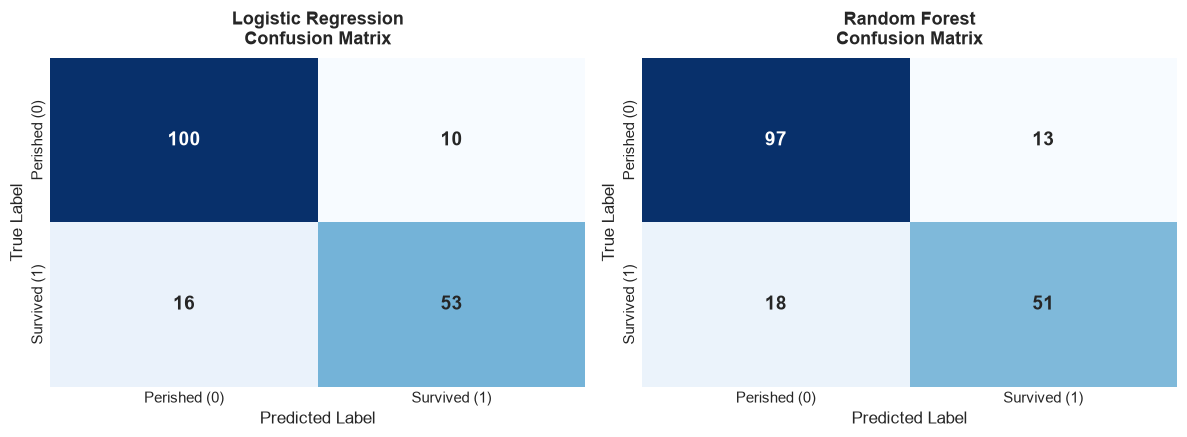

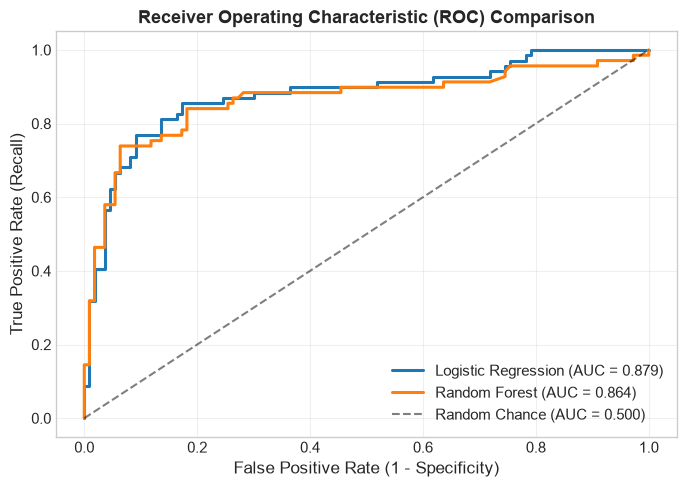

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for ax, (name, cm) in zip(axes, cm_dict.items()):
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues', cbar=False,
        xticklabels=['Perished (0)', 'Survived (1)'],
        yticklabels=['Perished (0)', 'Survived (1)'],
        ax=ax, annot_kws={'size': 14, 'weight': 'bold'}
    )
    ax.set_title(f"{name}\nConfusion Matrix", fontweight='bold', pad=10)
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')

plt.tight_layout()
plt.show()

# ROC Curves
plt.figure(figsize=(7, 5))
for name, (fpr, tpr, auc) in roc_dict.items():
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})", linewidth=2.2)
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random Chance (AUC = 0.500)')
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Recall)')
plt.title('Receiver Operating Characteristic (ROC) Comparison', fontweight='bold')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [12]:
for name, model in models.items():
    y_pred = model.predict(X_test)
    print(f"=== CLASSIFICATION REPORT: {name.upper()} ===")
    print(classification_report(y_test, y_pred, digits=4))


=== CLASSIFICATION REPORT: LOGISTIC REGRESSION ===
              precision    recall  f1-score   support

           0     0.8621    0.9091    0.8850       110
           1     0.8413    0.7681    0.8030        69

    accuracy                         0.8547       179
   macro avg     0.8517    0.8386    0.8440       179
weighted avg     0.8541    0.8547    0.8534       179

=== CLASSIFICATION REPORT: RANDOM FOREST ===
              precision    recall  f1-score   support

           0     0.8435    0.8818    0.8622       110
           1     0.7969    0.7391    0.7669        69

    accuracy                         0.8268       179
   macro avg     0.8202    0.8105    0.8146       179
weighted avg     0.8255    0.8268    0.8255       179



## 7. Model Interpretation & Feature Importance

To understand *how* the models make predictions:
* **Random Forest Feature Importance**: Mean Decrease in Impurity (Gini importance) indicates which features contributed most to partition purity across all decision trees.
* **Logistic Regression Coefficients**: Log-odds multipliers indicate positive vs negative survival impact.


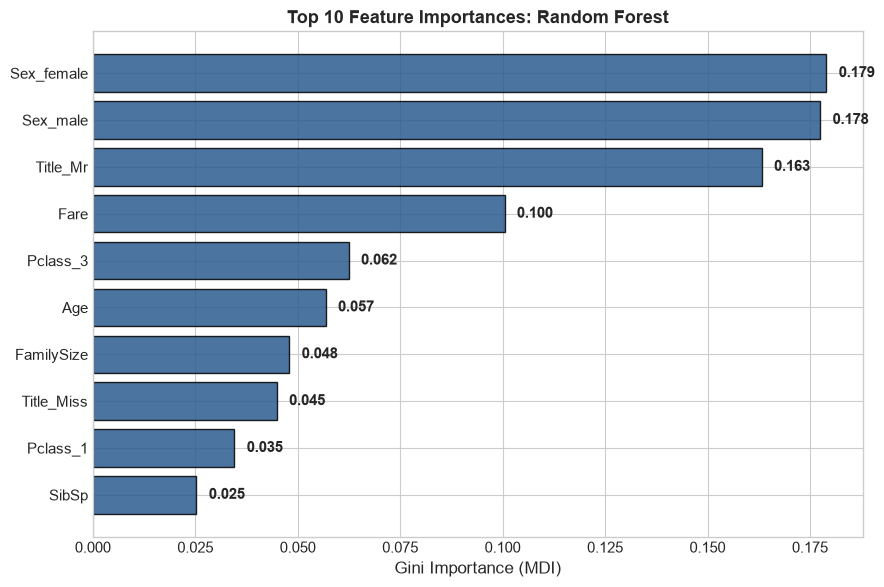

,Feature,Importance
5,Sex_female,0.179016
6,Sex_male,0.177515
17,Title_Mr,0.163230
1,Fare,0.100465
9,Pclass_3,0.062433
0,Age,0.056816
4,FamilySize,0.047956
16,Title_Miss,0.044877
7,Pclass_1,0.034543
2,SibSp,0.025286


In [13]:
# Extract feature names after ColumnTransformer preprocessing
feature_names = preprocessor.get_feature_names_out()
clean_names = [f.replace('num__', '').replace('cat__', '') for f in feature_names]

rf_classifier = rf_pipeline.named_steps['classifier']
rf_fi = pd.DataFrame({
    'Feature': clean_names,
    'Importance': rf_classifier.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(9, 6))
top_10 = rf_fi.head(10).sort_values(by='Importance', ascending=True)
bars = plt.barh(top_10['Feature'], top_10['Importance'], color='#2b5c8f', edgecolor='black', alpha=0.85)
plt.xlabel('Gini Importance (MDI)')
plt.title('Top 10 Feature Importances: Random Forest', fontweight='bold')
for bar in bars:
    w = bar.get_width()
    plt.text(w + 0.003, bar.get_y() + bar.get_height()/2, f"{w:.3f}", va='center', fontweight='bold')
plt.tight_layout()
plt.show()

display(rf_fi.head(10))


In [14]:
lr_classifier = lr_pipeline.named_steps['classifier']
lr_coef = pd.DataFrame({
    'Feature': clean_names,
    'Coefficient': lr_classifier.coef_[0],
    'Odds Ratio (e^coef)': np.exp(lr_classifier.coef_[0])
}).sort_values(by='Coefficient', ascending=False)

print("Top 5 Positive Survival Predictors (Logistic Regression):")
display(lr_coef.head(5))

print("\nTop 5 Negative Survival Predictors (Logistic Regression):")
display(lr_coef.tail(5))


Top 5 Positive Survival Predictors (Logistic Regression):


,Feature,Coefficient,Odds Ratio (e^coef)
15,Title_Master,1.382787,3.985995
7,Pclass_1,1.000876,2.720665
5,Sex_female,0.812842,2.254306
18,Title_Mrs,0.499579,1.648028
11,Embarked_Q,0.298532,1.347878



Top 5 Negative Survival Predictors (Logistic Regression):


,Feature,Coefficient,Odds Ratio (e^coef)
0,Age,-0.365727,0.693692
19,Title_Rare,-0.553522,0.574921
6,Sex_male,-0.800253,0.449215
9,Pclass_3,-0.963243,0.381653
17,Title_Mr,-1.227121,0.293135


## 8. Summary of Findings & Engineering Conclusions

### Key Quantitative Findings:
1. **Model Performance**:
   - **Logistic Regression**: Achieved **85.47% accuracy**, **0.8030 F1-score**, and an **ROC-AUC of 0.8791** on the 20% holdout test set (TN=100, FP=10, FN=16, TP=53).
   - **Random Forest**: Achieved **82.68% accuracy**, **0.7669 F1-score**, and **0.8641 ROC-AUC** (TN=97, FP=13, FN=18, TP=51).
   - *Why Logistic Regression excelled*: With strong linear separation from dominant features (`Sex`, `Title`, `Pclass`), the L2-regularized linear model generalized with minimal variance, avoiding subtle tree overfitting.
2. **Dominant Survival Signals**:
   - **Gender & Title**: `Sex_female` and `Title_Master` were the strongest positive drivers of survival, reflecting maritime evacuation protocol ("women and children first"). In contrast, `Title_Mr` and `Sex_male` had the strongest negative survival odds.
   - **Socioeconomic Class**: 1st class passengers (`Pclass_1`) had an odds ratio of **2.72**, whereas 3rd class passengers (`Pclass_3`) had an odds ratio of **0.38** (62% lower odds of surviving).
   - **Family Dynamics**: Medium family sizes (2 to 4 members) experienced higher survival rates than passengers traveling alone (`IsAlone=1`).

### Production & Architecture Best Practices Demonstrated:
- **Zero Data Leakage**: Scaler and imputer statistics fitted strictly on training folds inside scikit-learn `Pipeline`.
- **Reproducibility**: Explicit random states, modularized code, and version-pinned environments.
- **Explainability**: Combining tree-based MDI importance with linear odds ratios for end-to-end interpretability.
